In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

#Loading Data and Splitting

data_path = "../data/trait_counts_cleaned.csv"   
df = pd.read_csv(data_path)

X = df.drop(columns=["top_four"])
y = df["top_four"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          
)
feature_columns = df.drop(columns = ['top_four']).columns.tolist()

ensemble_training_data = pd.DataFrame(X_train, columns = feature_columns)
ensemble_training_data.to_csv("../data/ensemble_training_data.csv", index=False)

ensemble_testing_data = pd.DataFrame(X_test, columns = feature_columns)
ensemble_testing_data.to_csv("../data/ensemble_testing_data.csv", index=False)


Accuracy: 0.6908077994428969


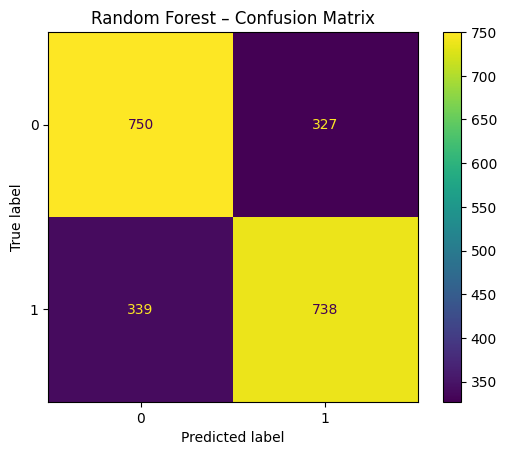

Classification Report:

              precision    recall  f1-score   support

           0      0.689     0.696     0.693      1077
           1      0.693     0.685     0.689      1077

    accuracy                          0.691      2154
   macro avg      0.691     0.691     0.691      2154
weighted avg      0.691     0.691     0.691      2154



In [12]:
#Fitting Random Forest

rf = RandomForestClassifier(
    n_estimators=300,      
    max_depth=None,       
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",  
    random_state=42,
    n_jobs=-1             
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot()
plt.title("Random Forest – Confusion Matrix")
plt.show()

print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=3))